<a href="https://colab.research.google.com/github/souricebunny/NeuroMarketing/blob/main/LaysAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"


Using Python 3.12.13 environment at: /usr
Resolved 138 packages in 894ms
Checked 138 packages in 2ms


In [4]:
!pip install torchaudio==2.6.0 --force-reinstall --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.


In [1]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-06-30 16:15:17 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


config.yaml:   0%|          | 0.00/18.0k [00:00<?, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-06-30 16:15:39 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

In [3]:
from google.colab import files
uploaded = files.upload()

Saving LAY'S Presents - More smiles per mile - Frito Lay's India (360p, h264, youtube).mp4 to LAY'S Presents - More smiles per mile - Frito Lay's India (360p, h264, youtube).mp4


In [4]:
video_path = "/content/LAY'S Presents - More smiles per mile - Frito Lay's India (360p, h264, youtube).mp4"

df = model.get_events_dataframe(video_path=video_path)
df = df[df['type'].isin(['Video', 'Audio'])].reset_index(drop=True)
df = df[df['start'] <= 10].reset_index(drop=True)

print(f"Total events: {len(df)}")
print(df['type'].value_counts())
display(df.head(8)[["type", "start", "duration"]])

Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in /content/LAY'S Presents - More smiles per mile - Frito Lay's India (360p, h264, youtube).wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  2.74it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


MoviePy - Done.


Extracting words from audio: 100%|██████████| 1/1 [03:46<00:00, 226.73s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Add context to words: 100%|██████████| 5/5 [00:00<00:00, 29208.25it/s]

Total events: 2
type
Audio    1
Video    1
Name: count, dtype: int64


,type,start,duration
0,Audio,0.0,25.09
1,Video,0.0,25.09


In [5]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

[16:24:02 WARNING] Removing extractor text as there are no corresponding events
[16:24:02 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

video_preprocessor_config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

2026-06-30 16:26:19 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 25.09s at 25.0fps, shape (640, 360)):
/content/LAY'S Presents - More smiles per mile - Frito Lay's India (360p, h264, youtube).mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 25.09s at 25.0fps, shape (640, 360)):
/content/LAY'S Presents - More smiles per mile - Frito Lay's India (360p, h264, youtube).mp4
Encoding video:   0%|          | 0/50 [00:00<?, ?it/s]2026-06-30 16:26:39 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (50, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (50, 20, 1408)
Encoding video: 100%|██████████| 50/50 [13:44<00:00, 16.49s/it]
[16:40:04 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-06-30 16:40:04 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[16:40:04 INFO] Building dataloader for split all
INFO:t

Predictions shape: (26, 20484)  (n_timesteps, n_vertices)


Plotting...: 100%|██████████| 15/15 [00:04<00:00,  3.29it/s]


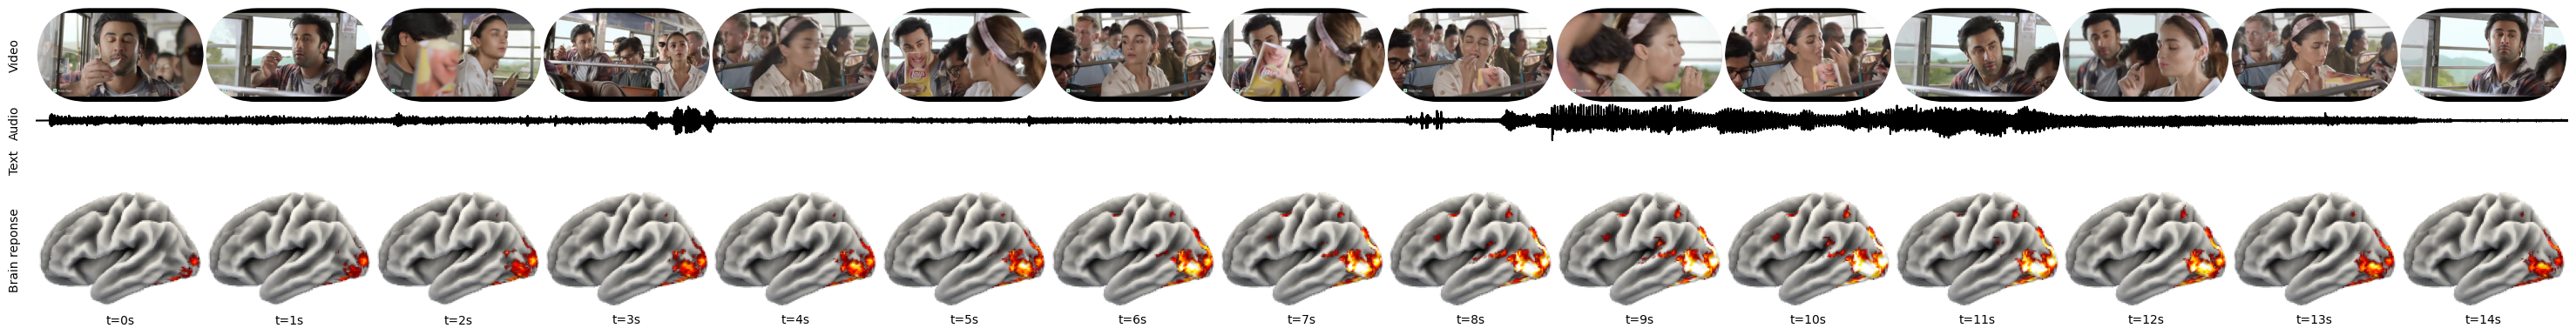

In [6]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)